An **order-$n$ Magic P-hexagon** is a hexagonal arrangement of the integers from $1$ to $6 n^2$ such that the sum of the four numbers in every $2 \times 2$ subtriangle is the same.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from dataclasses import dataclass

SQRT3 = np.sqrt(3)
H = SQRT3 / 2

# ------------------------------------------------------------
# Six boundary directions
#
# sides = (a,b,c,d,e,f)
#
# a = top horizontal side, followed clockwise.
#
# A zero-length side is allowed.  It represents a degenerate
# side: no movement occurs, but the boundary direction advances.
# ------------------------------------------------------------

DIRECTIONS = np.array([
    [ 1.0,  0.0],
    [ 0.5, -H],
    [-0.5, -H],
    [-1.0,  0.0],
    [-0.5,  H],
    [ 0.5,  H],
])


# ============================================================
# Result object for inverse analysis
# ============================================================

@dataclass
class ShapeAnalysis:
    status: str
    row_lengths: tuple
    n_rows: int
    n_cells: int
    candidates: tuple
    reason: str = ""

    @property
    def is_valid(self):
        return self.status in ("unique", "ambiguous")

    @property
    def is_unique(self):
        return self.status == "unique"

    @property
    def sides(self):
        if self.is_unique:
            return self.candidates[0]
        return None


# ============================================================
# 1. Boundary
# ============================================================

def boundary_vertices(sides):
    """
    Return boundary vertices for sides=(a,b,c,d,e,f).

    Convention:
        - a is the top horizontal side.
        - boundary is followed clockwise.
        - zero-length sides are allowed.
    """

    if len(sides) != 6:
        raise ValueError("sides must contain exactly six integers.")

    sides = tuple(int(x) for x in sides)

    if any(x < 0 for x in sides):
        raise ValueError("side lengths must be nonnegative.")

    p = np.array([0.0, 0.0])
    vertices = [p.copy()]

    for length, direction in zip(sides, DIRECTIONS):
        p = p + length * direction
        vertices.append(p.copy())

    return np.array(vertices)


def is_closed(sides, tol=1e-9):
    """Check whether the six sides form a closed boundary."""
    v = boundary_vertices(sides)
    return np.linalg.norm(v[-1] - v[0]) < tol


# ============================================================
# 2. Enumerate unit triangular cells
# ============================================================

def triangular_cells(sides):
    """
    Enumerate all unit triangular cells inside the boundary.

    Each returned item contains:
        orientation : 'up' or 'down'
        vertices    : 3x2 array
        center      : centroid
        strip       : horizontal row index
    """

    if not is_closed(sides):
        raise ValueError(
            f"sides={tuple(sides)} does not form a closed region."
        )

    boundary = boundary_vertices(sides)

    # Repeated vertices caused by zero sides are harmless.
    polygon = Path(boundary[:-1])

    xmin = boundary[:, 0].min()
    xmax = boundary[:, 0].max()

    ymin = boundary[:, 1].min()
    ymax = boundary[:, 1].max()

    kmin = int(np.floor(ymin / H)) - 2
    kmax = int(np.ceil(ymax / H)) + 2

    # Safe horizontal search range.
    imin = int(np.floor(xmin)) - max(sides) - 3
    imax = int(np.ceil(xmax)) + max(sides) + 3

    cells = []

    for k in range(kmin, kmax + 1):

        # Lattice points on horizontal level k are
        #
        # x = i + k/2
        # y = k H

        for i in range(imin, imax + 1):

            x = i + k / 2
            y = k * H

            # upward triangle
            up = np.array([
                [x,       y],
                [x + 1.0, y],
                [x + 0.5, y + H],
            ])

            # downward triangle
            down = np.array([
                [x,       y],
                [x + 1.0, y],
                [x + 0.5, y - H],
            ])

            for orientation, tri in (
                ("up", up),
                ("down", down),
            ):

                center = tri.mean(axis=0)

                # For these lattice polygons the centroid test is
                # sufficient to determine the unit cells belonging
                # to the region.
                if polygon.contains_point(center, radius=1e-9):

                    levels = tri[:, 1] / H
                    strip = int(round(levels.min()))

                    cells.append({
                        "orientation": orientation,
                        "vertices": tri,
                        "center": center,
                        "strip": strip,
                    })

    return cells


# ============================================================
# 3. Convert sides -> rows
# ============================================================

def cells_by_row(sides):
    """
    Return unit triangular cells grouped into horizontal rows,
    from top to bottom.
    """

    cells = triangular_cells(sides)

    rows = {}

    for cell in cells:
        rows.setdefault(cell["strip"], []).append(cell)

    # larger strip = visually higher
    ordered = []

    for strip in sorted(rows, reverse=True):

        row = rows[strip]

        # left-to-right
        row.sort(key=lambda c: c["center"][0])

        ordered.append(row)

    return ordered


def row_lengths_from_sides(sides):
    """
    Example:
        (0,3,0,3,0,3) -> (1,3,5)
        (1,3,3,1,3,3) -> (3,5,7,7,5,3)
        (2,2,2,2,2,2) -> (5,7,7,5)
    """

    return tuple(len(row) for row in cells_by_row(sides))


def cell_count_from_sides(sides):
    return sum(row_lengths_from_sides(sides))


# ============================================================
# 4. Some Jigusugwimundo families
# ============================================================

def jigusugwimundo_sides(n, kind="rhombic"):
    """
    Convert a named family and order n to sides=(a,b,c,d,e,f).

    n is measured in unit-triangle edges.
    """

    if not isinstance(n, (int, np.integer)) or n < 1:
        raise ValueError("n must be a positive integer.")

    if kind == "triangle":

        # ordinary triangular array
        return (0, n, 0, n, 0, n)

    elif kind == "rhombic":

        # conventional order-n Jigusugwimundo form
        return (1, n, n, 1, n, n)

    elif kind == "regular_hexagon":

        return (n, n, n, n, n, n)

    else:
        raise ValueError(
            f"Unknown kind {kind!r}. "
            "Use 'triangle', 'rhombic', or 'regular_hexagon'."
        )


# ============================================================
# 5. Inverse problem: data -> possible sides
# ============================================================

def analyze_jigusugwimundo_shape(data, max_side=None):
    """
    Infer possible (a,b,c,d,e,f) from row lengths alone.

    Returns
    -------
    ShapeAnalysis

    status:
        'unique'
            exactly one six-side representation was found

        'ambiguous'
            two or more geometrically different representations
            have exactly the same row lengths

        'invalid'
            no representation was found

    Important
    ---------
    Row lengths do NOT always determine the geometry uniquely.
    Odd/even transitions are one important source of ambiguity.
    """

    if len(data) == 0:
        return ShapeAnalysis(
            status="invalid",
            row_lengths=(),
            n_rows=0,
            n_cells=0,
            candidates=(),
            reason="data contains no rows.",
        )

    row_lengths = tuple(len(row) for row in data)

    if any(L <= 0 for L in row_lengths):
        return ShapeAnalysis(
            status="invalid",
            row_lengths=row_lengths,
            n_rows=len(row_lengths),
            n_cells=sum(row_lengths),
            candidates=(),
            reason="Every row must contain at least one triangle.",
        )

    n_rows = len(row_lengths)
    n_cells = sum(row_lengths)

    # A deliberately conservative automatic bound.
    #
    # The user can increase this for unusual large shapes.
    if max_side is None:
        max_side = max(max(row_lengths), n_rows) + 1

    candidates = []

    # --------------------------------------------------------
    # Closure conditions reduce the six-dimensional search.
    #
    # With our direction convention:
    #
    #     a + b = d + e
    #     b + c = e + f
    #
    # so once a,b,c,d are selected:
    #
    #     e = a+b-d
    #     f = b+c-e
    #
    # --------------------------------------------------------

    for a in range(max_side + 1):
        for b in range(max_side + 1):
            for c in range(max_side + 1):
                for d in range(max_side + 1):

                    e = a + b - d

                    if e < 0 or e > max_side:
                        continue

                    f = b + c - e

                    if f < 0 or f > max_side:
                        continue

                    sides = (a, b, c, d, e, f)

                    if sum(sides) == 0:
                        continue

                    try:
                        generated = row_lengths_from_sides(sides)
                    except ValueError:
                        continue

                    # Crucial step:
                    # reconstruct forward and compare exactly.
                    if generated == row_lengths:
                        candidates.append(sides)

    # Remove exact duplicates
    candidates = tuple(sorted(set(candidates)))

    if len(candidates) == 0:

        return ShapeAnalysis(
            status="invalid",
            row_lengths=row_lengths,
            n_rows=n_rows,
            n_cells=n_cells,
            candidates=(),
            reason=(
                "No six-side triangular-grid region reproduces "
                "these row lengths within the search bound."
            ),
        )

    elif len(candidates) == 1:

        return ShapeAnalysis(
            status="unique",
            row_lengths=row_lengths,
            n_rows=n_rows,
            n_cells=n_cells,
            candidates=candidates,
            reason="The six-side representation is unique.",
        )

    else:

        return ShapeAnalysis(
            status="ambiguous",
            row_lengths=row_lengths,
            n_rows=n_rows,
            n_cells=n_cells,
            candidates=candidates,
            reason=(
                "The row lengths are geometrically valid, but "
                "do not uniquely determine the six-side boundary."
            ),
        )


# ============================================================
# 6. Validate data against known sides
# ============================================================

def validate_data_shape(data, sides):
    """
    Check whether data has exactly the row structure required
    by sides=(a,b,c,d,e,f).
    """

    actual = tuple(len(row) for row in data)
    expected = row_lengths_from_sides(sides)

    if actual != expected:
        raise ValueError(
            "Invalid data shape.\n"
            f"Expected row lengths: {expected}\n"
            f"Actual row lengths:   {actual}"
        )

    return True


# ============================================================
# 7. Plot
# ============================================================

def plot_jigusugwimundo(
    data,
    sides,
    title=None,
    fontsize=13,
    figsize=(9, 9),
):
    """
    Plot data on the triangular-grid region defined by sides.
    """

    validate_data_shape(data, sides)

    rows = cells_by_row(sides)

    fig, ax = plt.subplots(figsize=figsize)

    all_x = []
    all_y = []

    for values, cells in zip(data, rows):

        for value, cell in zip(values, cells):

            tri = cell["vertices"]
            center = cell["center"]

            polygon = plt.Polygon(
                tri,
                closed=True,
                fill=False,
                edgecolor="black",
                linewidth=1,
            )

            ax.add_patch(polygon)

            ax.text(
                center[0],
                center[1],
                str(value),
                ha="center",
                va="center",
                fontsize=fontsize,
                color="black",
            )

            all_x.extend(tri[:, 0])
            all_y.extend(tri[:, 1])

    ax.set_aspect("equal")
    ax.axis("off")

    margin = 0.2

    ax.set_xlim(
        min(all_x) - margin,
        max(all_x) + margin
    )

    ax.set_ylim(
        min(all_y) - margin,
        max(all_y) + margin
    )

    if title is not None:
        ax.set_title(
            str(title),
            fontsize=fontsize + 2,
            color="black",
            pad=8,
        )

    plt.tight_layout(pad=0.2)
    plt.show()

In [3]:
def plot_jigusugwimundo_labeled(
    labels,
    numbers,
    sides,
    title=None,
    fontsize=11,
    figsize=(9, 9),
    line_spacing=0.85,
):
    """
    Plot a triangular-grid region with two-line labels.

    Each triangular cell displays:

        label
        number

    Parameters
    ----------
    labels : list[list]
        Character/name array.

    numbers : list[list]
        Numeric value array.

    sides : tuple
        (a, b, c, d, e, f)

    title : str, optional
        Plot title.

    fontsize : int
        Font size for both labels and numbers.

    figsize : tuple
        Figure size.

    line_spacing : float
        Spacing between the label and number lines.
    """

    # --------------------------------------------------------
    # 1. Validate both arrays
    # --------------------------------------------------------

    validate_data_shape(labels, sides)
    validate_data_shape(numbers, sides)

    if len(labels) != len(numbers):
        raise ValueError(
            "labels and numbers must have the same number of rows."
        )

    for i, (label_row, number_row) in enumerate(
        zip(labels, numbers)
    ):
        if len(label_row) != len(number_row):
            raise ValueError(
                f"Row {i}: labels and numbers have different lengths."
            )

    # --------------------------------------------------------
    # 2. Get triangular cells
    # --------------------------------------------------------

    rows = cells_by_row(sides)

    fig, ax = plt.subplots(figsize=figsize)

    all_x = []
    all_y = []

    # --------------------------------------------------------
    # 3. Draw cells and two-line text
    # --------------------------------------------------------

    for label_row, number_row, cells in zip(
        labels, numbers, rows
    ):

        for label, number, cell in zip(
            label_row, number_row, cells
        ):

            tri = cell["vertices"]
            center = cell["center"]

            polygon = plt.Polygon(
                tri,
                closed=True,
                fill=False,
                edgecolor="black",
                linewidth=1,
            )

            ax.add_patch(polygon)

            ax.text(
                center[0],
                center[1],
                f"{label}\n{number}",
                ha="center",
                va="center",
                multialignment="center",
                fontsize=fontsize,
                color="black",
                linespacing=line_spacing,
            )

            all_x.extend(tri[:, 0])
            all_y.extend(tri[:, 1])

    # --------------------------------------------------------
    # 4. Plot formatting
    # --------------------------------------------------------

    ax.set_aspect("equal")
    ax.axis("off")

    margin = 0.2

    ax.set_xlim(
        min(all_x) - margin,
        max(all_x) + margin
    )

    ax.set_ylim(
        min(all_y) - margin,
        max(all_y) + margin
    )

    if title is not None:
        ax.set_title(
            str(title),
            fontsize=fontsize + 2,
            color="black",
            pad=8,
        )

    plt.tight_layout(pad=0.2)
    plt.show()

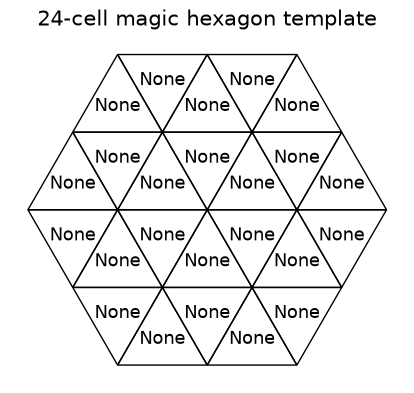

In [4]:
def empty_hexagon_data(sides):
    """
    Create an empty data array matching the triangular-cell
    row structure of sides=(a,b,c,d,e,f).

    Empty cells are represented by None.
    """

    # 기존 함수가 있다면 이것을 그대로 이용
    lengths = row_lengths_from_sides(sides)

    return [
        [None] * length
        for length in lengths
    ]


def print_empty_hexagon_data(sides, variable_name="data"):
    """
    Print copy-pasteable Python code for an empty array
    matching sides=(a,b,c,d,e,f).
    """

    data = empty_hexagon_data(sides)

    print(f"{variable_name} = [")

    for row in data:
        contents = ", ".join("None" for _ in row)
        print(f"    [{contents}],")

    print("]")
    
    
plot_jigusugwimundo(
    empty_hexagon_data((2, 2, 2, 2, 2, 2)),
    sides=(2, 2, 2, 2, 2, 2),
    title="24-cell magic hexagon template",
    fontsize=13,
    figsize=(4, 4),
)

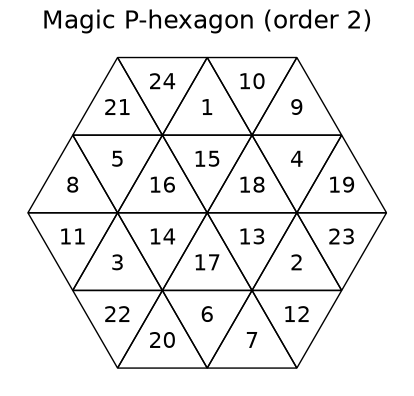

In [5]:
magicPorder2 = [
    [21, 24, 1, 10, 9],
    [8, 5, 16, 15, 18, 4, 19],
    [11, 3, 14, 17, 13, 2, 23],
    [22, 20, 6, 7, 12],
]
plot_jigusugwimundo(
    magicPorder2,
    sides=(2, 2, 2, 2, 2, 2),
    title="Magic P-hexagon (order 2)",
    fontsize=16,
    figsize=(4, 4),
)

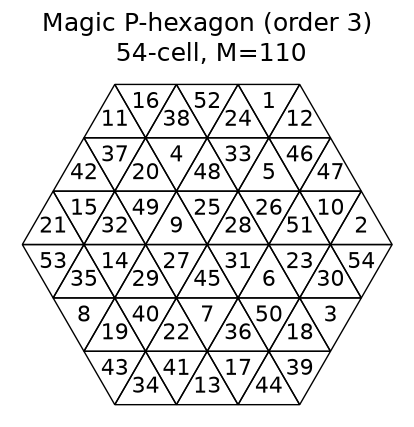

In [6]:
magicPorder3 =  [
    [11, 16, 38, 52, 24, 1, 12],
    [42, 37, 20, 4, 48, 33, 5, 46, 47],
    [21, 15, 32, 49, 9, 25, 28, 26, 51, 10, 2],
    [53, 35, 14, 29, 27, 45, 31, 6, 23, 30, 54],
    [8, 19, 40, 22, 7, 36, 50, 18, 3],
    [43, 34, 41, 13, 17, 44, 39]
]
ROWS = [
    ["HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1"],
    ["HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1"],
    ["HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1"],
    ["HCA1", "YCA1", "CA1", "C1", "A1", "B0", "A2", "C2", "AC2", "ZAC2", "HAC2"],
    ["HC1", "YAC1", "AC1", "DB0", "D0", "BD0", "CA2", "ZCA2", "HC2"],
    ["HAC1", "HDB0", "XDB0", "HD0", "XBD0", "HBD0", "HCA2"],
]
plot_jigusugwimundo(
    magicPorder3,
    sides=(3, 3, 3, 3, 3, 3),
    title="Magic P-hexagon (order 3)\n 54-cell, M=110",
    fontsize=16,
    figsize=(4, 4),
)

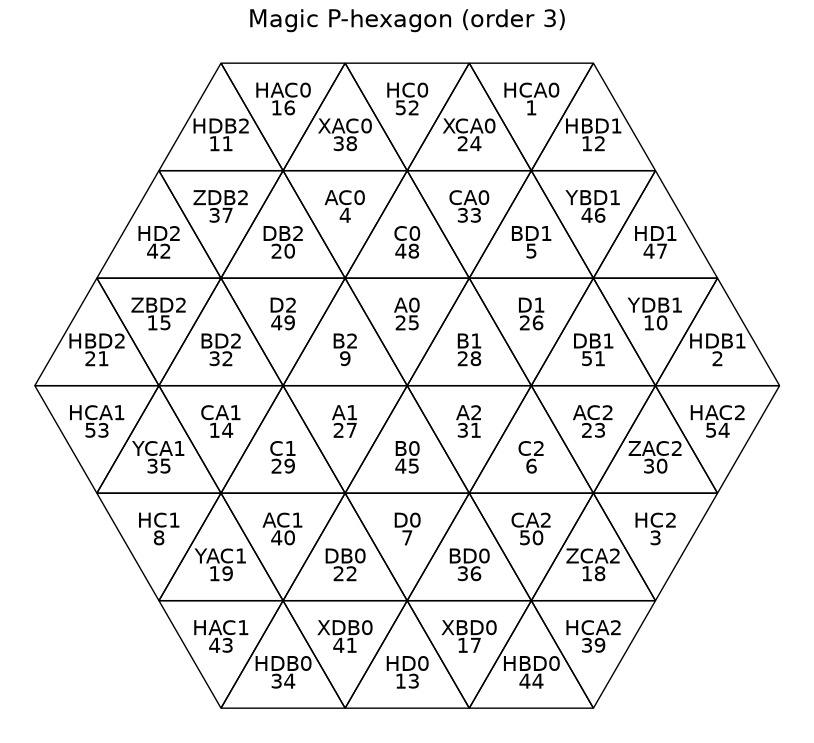

In [7]:
plot_jigusugwimundo_labeled(
    ROWS,magicPorder3,
    sides=(3, 3, 3, 3, 3, 3),
    title="Magic P-hexagon (order 3)",
    fontsize=15,
    figsize=(8, 8),
)

In [8]:
#python code
"""Search the 54-cell triangular hexagon with every side-2 triangle summing to 110.

Input: As.npy and Bs.npy containing the previously generated rows of three
integers. Usage: python search_magic_hexagon_54.py As.npy Bs.npy --limit 1
"""

import argparse
import time
from collections import defaultdict
import itertools
import numpy as np


As=np.zeros([351,3],dtype=int)
j=0
for A in itertools.combinations(range(1,55), 3):
    if A[0]+A[1]+A[2]==83:
        j+=1
        As[-j,:]=A
Bs=np.zeros([351*6,3],dtype=int)
j=0
for B in itertools.permutations(range(1,55), 3):
    if B[0]+B[1]+B[2]==82:
        Bs[j,:]=B
        j+=1
print(j)

ROWS = [
    ["HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1"],
    ["HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1"],
    ["HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1"],
    ["HCA1", "YCA1", "CA1", "C1", "A1", "B0", "A2", "C2", "AC2", "ZAC2", "HAC2"],
    ["HC1", "YAC1", "AC1", "DB0", "D0", "BD0", "CA2", "ZCA2", "HC2"],
    ["HAC1", "HDB0", "XDB0", "HD0", "XBD0", "HBD0", "HCA2"],
]


def make_triangles():
    """Enumerate all geometric 2-by-2 triangles, independently of the search."""
    starts = (3, 2, 1, 1, 2, 3)
    pos = {(r, starts[r] + j): name
           for r, row in enumerate(ROWS) for j, name in enumerate(row)}
    triangles = []
    for r, row in enumerate(ROWS):
        for j, name in enumerate(row):
            x = starts[r] + j
            points_up = (j % 2 == 0) if r < 3 else (j % 2 == 1)
            # An upward small triangle shares its horizontal edge below;
            # a downward one shares it above, in either half of the hexagon.
            adjacent_row = r + (1 if points_up else -1)
            neighbors = [pos.get((r, x - 1)), pos.get((r, x + 1)),
                         pos.get((adjacent_row, x))]
            if all(neighbors):
                triangles.append((name, *neighbors))
    return triangles


TRIANGLES = make_triangles()
ALL_NAMES = {name for row in ROWS for name in row}


def add(assign, used, pairs):
    """Add a batch of calculated values; reject out-of-range or reused values."""
    new = dict(assign)
    for name, value in pairs:
        value = int(value)
        if not 1 <= value <= 54 or name in new or used & (1 << value):
            return None
        new[name] = value
        used |= 1 << value
    return new, used


def choices(assign, used, name):
    for value in range(1, 55):
        if not used & (1 << value):
            result = add(assign, used, ((name, value),))
            if result is not None:
                yield result


def verify(solution):
    return (set(solution) == ALL_NAMES
            and set(solution.values()) == set(range(1, 55))
            and all(sum(solution[name] for name in triangle) == 110
                    for triangle in TRIANGLES))


def search(As, Bs, limit=1, base_limit=None):
    """Yield complete solutions; choose six edge midpoints after 36 inner cells."""
    grouped_b = defaultdict(list)
    for row in Bs:
        b = tuple(map(int, row))
        if len(b) == 3 and len(set(b)) == 3:
            grouped_b[sum(b)].append(b)

    base_count = found = 0
    for row in As:
        a = tuple(map(int, row))
        if len(a) != 3 or len(set(a)) != 3:
            continue
        for b in grouped_b[165 - sum(a)]:
            if len(set(a + b)) != 6:
                continue
            A0, A1, A2 = a
            B0, B1, B2 = b
            c = (110-A0-B1-B2, 110-A1-B0-B2, 110-A2-B0-B1)
            d = (110-B0-A1-A2, 110-B1-A0-A2, 110-B2-A0-A1)
            base_values = a + b + c + d
            if len(set(base_values)) != 12 or not all(1 <= x <= 54 for x in base_values):
                continue
            base_count += 1
            if base_limit is not None and base_count > base_limit:
                return
            p = dict(zip(("A0", "A1", "A2", "B0", "B1", "B2",
                          "C0", "C1", "C2", "D0", "D1", "D2"), base_values))
            used = sum(1 << x for x in base_values)
            C0, C1, C2 = c
            D0, D1, D2 = d

            # First finish the 36 cells without an H prefix.
            for p1, u1 in choices(p, used, "AC0"):
                AC0 = p1["AC0"]
                CA0 = 110-A0-C0-AC0
                q1 = add(p1, u1, (("CA0", CA0),))
                if q1 is None:
                    continue
                for p2, u2 in choices(*q1, "XAC0"):
                    XAC0 = p2["XAC0"]
                    DB2 = 110-AC0-C0-XAC0
                    ZDB2 = 110-DB2-D2-AC0
                    BD2 = 110-D2-B2-DB2
                    q2 = add(p2, u2, (("DB2", DB2), ("ZDB2", ZDB2),
                                       ("BD2", BD2)))
                    if q2 is None:
                        continue
                    for p3, u3 in choices(*q2, "XCA0"):
                        XCA0 = p3["XCA0"]
                        BD1 = 110-CA0-C0-XCA0
                        YBD1 = 110-BD1-D1-CA0
                        DB1 = 110-D1-B1-BD1
                        q3 = add(p3, u3, (("BD1", BD1), ("YBD1", YBD1),
                                           ("DB1", DB1)))
                        if q3 is None:
                            continue
                    
                        for p4, u4 in choices(*q3, "CA1"):
                            CA1 = p4["CA1"]
                            YCA1 = 110-CA1-C1-BD2
                            AC1 = 110-C1-CA1-A1
                            ZBD2 = 110-BD2-D2-CA1
                            q4 = add(p4, u4, (("YCA1", YCA1), ("AC1", AC1),
                                               ("ZBD2", ZBD2)))
                            if q4 is None:
                                continue
                            for p5, u5 in choices(*q4, "AC2"):
                                AC2 = p5["AC2"]
                                CA2 = 110-C2-A2-AC2
                                ZAC2 = 110-AC2-C2-DB1
                                YDB1 = 110-DB1-D1-AC2
                                q5 = add(p5, u5, (("CA2", CA2), ("ZAC2", ZAC2),
                                                   ("YDB1", YDB1)))
                                if q5 is None:
                                    continue
                                for p6, u6 in choices(*q5, "DB0"):
                                    DB0 = p6["DB0"]
                                    BD0 = 110-D0-B0-DB0
                                    XDB0 = 110-DB0-AC1-D0
                                    YAC1 = 110-AC1-DB0-C1
                                    XBD0 = 110-BD0-D0-CA2
                                    ZCA2 = 110-CA2-BD0-C2
                                    q6 = add(p6, u6, (("BD0", BD0), ("XDB0", XDB0),
                                                       ("YAC1", YAC1), ("XBD0", XBD0),
                                                       ("ZCA2", ZCA2)))
                                    if q6 is None:
                                        continue
                                    assert len(q6[0]) == 36

                                    # Each midpoint choice fills three H cells.
                                    for p7, u7 in choices(*q6, "HC0"):
                                        HC0 = p7["HC0"]
                                        q7 = add(p7, u7,
                                                 (("HAC0", 110-XAC0-HC0-AC0),
                                                  ("HCA0", 110-XCA0-HC0-CA0)))
                                        if q7 is None:
                                            continue
                                    
                                        for p8, u8 in choices(*q7, "HD2"):
                                            HD2 = p8["HD2"]
                                            q8 = add(p8, u8,
                                                     (("HDB2", 110-ZDB2-DB2-HD2),
                                                      ("HBD2", 110-ZBD2-BD2-HD2)))
                                            if q8 is None:
                                                continue
                                            for p9, u9 in choices(*q8, "HD1"):
                                                HD1 = p9["HD1"]
                                                q9 = add(p9, u9,
                                                         (("HBD1", 110-YBD1-BD1-HD1),
                                                          ("HDB1", 110-YDB1-DB1-HD1)))
                                                if q9 is None:
                                                    continue
                                                for p10, u10 in choices(*q9, "HC1"):
                                                    HC1 = p10["HC1"]
                                                    q10 = add(p10, u10,
                                                              (("HCA1", 110-YCA1-CA1-HC1),
                                                               ("HAC1", 110-YAC1-AC1-HC1)))
                                                    if q10 is None:
                                                        continue
                                                    for p11, u11 in choices(*q10, "HC2"):
                                                        HC2 = p11["HC2"]
                                                        q11 = add(p11, u11,
                                                                  (("HAC2", 110-ZAC2-AC2-HC2),
                                                                   ("HCA2", 110-ZCA2-CA2-HC2)))
                                                        if q11 is None:
                                                            continue
                                                        for p12, u12 in choices(*q11, "HD0"):
                                                            HD0 = p12["HD0"]
                                                            q12 = add(p12, u12,
                                                                      (("HDB0", 110-XDB0-DB0-HD0),
                                                                       ("HBD0", 110-XBD0-BD0-HD0)))
                                                            if q12 is not None and verify(q12[0]):
                                                                found += 1
                                                                yield q12[0]
                                                                if limit is not None and found >= limit:
                                                                    return


def main():
    started = time.time()
    count = 0

    for solution in search(As, Bs, limit=1, base_limit=None):
        count += 1
        print(f"Solution {count}:")
        for row in ROWS:
            print(" ".join(f"{solution[name]:2d}" for name in row))
        print("Names:", solution, flush=True)

    print(f"Found {count} solution(s) in {time.time() - started:.2f} s")

'''
if __name__ == "__main__":
    main()
'''

2106


'\nif __name__ == "__main__":\n    main()\n'

In [9]:
#C code
'''

/* 54 triangular cells; every geometric side-2 triangle has sum 110.
 * Build: gcc -O3 -std=c11 -Wall -Wextra search_magic_hexagon_54.c -o search54
 * Run:   ./search54 --limit 1
 * Windows (MinGW): gcc -O3 -std=c11 search_magic_hexagon_54.c -o search54.exe
 *                  search54.exe --limit 1
 * The As (sum 83) and Bs (sum 82) arrays are generated internally.
 */

#include <inttypes.h>
#include <stdint.h>
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <time.h>

enum {
    HDB2, HAC0, XAC0, HC0, XCA0, HCA0, HBD1,
    HD2, ZDB2, DB2, AC0, C0, CA0, BD1, YBD1, HD1,
    HBD2, ZBD2, BD2, D2, B2, A0, B1, D1, DB1, YDB1, HDB1,
    HCA1, YCA1, CA1, C1, A1, B0, A2, C2, AC2, ZAC2, HAC2,
    HC1, YAC1, AC1, DB0, D0, BD0, CA2, ZCA2, HC2,
    HAC1, HDB0, XDB0, HD0, XBD0, HBD0, HCA2,
    CELL_COUNT
};

static const char *const names[CELL_COUNT] = {
    "HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1",
    "HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1",
    "HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1",
    "HCA1", "YCA1", "CA1", "C1", "A1", "B0", "A2", "C2", "AC2", "ZAC2", "HAC2",
    "HC1", "YAC1", "AC1", "DB0", "D0", "BD0", "CA2", "ZCA2", "HC2",
    "HAC1", "HDB0", "XDB0", "HD0", "XBD0", "HBD0", "HCA2"
};

static const int row_len[6] = {7, 9, 11, 11, 9, 7};
static const int row_off[6] = {0, 7, 16, 27, 38, 47};
static const int row_start[6] = {3, 2, 1, 1, 2, 3};
static const int choice_id[12] = {
    AC0, XAC0, XCA0, CA1, AC2, DB0,
    HC0, HD2, HD1, HC1, HC2, HD0
};

typedef struct { int v[CELL_COUNT]; } State;
typedef struct { int x[3]; } Triple;
typedef struct { int x[4]; } Quad;

static Triple as[351], bs[2106];
static Quad triangles[36];
static int na, nb, nt;
static uint64_t found, base_count, nodes;
static uint64_t limit = 1, base_limit, node_limit;
static int stop_search;
static clock_t begun;

static int at(int r, int x) {
    if (r < 0 || r >= 6) return -1;
    int j = x - row_start[r];
    return (j >= 0 && j < row_len[r]) ? row_off[r] + j : -1;
}

static void build_triangles(void) {
    int upper = 0, lower = 0;
    for (int r = 0; r < 6; ++r) {
        for (int j = 0; j < row_len[r]; ++j) {
            int x = row_start[r] + j;
            int up = (r < 3) ? !(j & 1) : (j & 1);
            int left = at(r, x - 1);
            int right = at(r, x + 1);
            int vertical = at(r + (up ? 1 : -1), x);
            if (left < 0 || right < 0 || vertical < 0) continue;
            if (nt >= 36) { fputs("Triangle geometry overflow\n", stderr); exit(2); }
            Quad *q = &triangles[nt++];
            q->x[0] = at(r, x);
            q->x[1] = left;
            q->x[2] = right;
            q->x[3] = vertical;
            if (r < 3) ++upper; else ++lower;
        }
    }
    if (CELL_COUNT != 54 || nt != 36 || upper != 18 || lower != 18) {
        fputs("Incorrect cell or triangle geometry\n", stderr);
        exit(2);
    }
}

static void build_inputs(void) {
    /* Python As[-j] reverses the lexicographic combination order. */
    for (int a = 1; a <= 54; ++a)
        for (int b = a + 1; b <= 54; ++b) {
            int c = 83 - a - b;
            if (c > b && c <= 54) {
                if (na >= 351) { fputs("As overflow\n", stderr); exit(2); }
                as[na++] = (Triple){{a, b, c}};
            }
        }
    for (int a = 1; a <= 54; ++a)
        for (int b = 1; b <= 54; ++b) {
            int c = 82 - a - b;
            if (c >= 1 && c <= 54 && a != b && b != c && c != a) {
                if (nb >= 2106) { fputs("Bs overflow\n", stderr); exit(2); }
                bs[nb++] = (Triple){{a, b, c}};
            }
        }
    if (na != 351 || nb != 2106) {
        fprintf(stderr, "Unexpected As/Bs sizes: %d/%d\n", na, nb);
        exit(2);
    }
}

/* 0 marks failure; bit 0 is never used, so a valid mask is nonzero. */
static uint64_t place(State *s, uint64_t used,
                      const int *ids, const int *values, int n) {
    uint64_t next = used;
    for (int i = 0; i < n; ++i) {
        int value = values[i];
        if (value < 1 || value > 54) return 0;
        uint64_t bit = UINT64_C(1) << value;
        if (next & bit) return 0;
        next |= bit;
    }
    for (int i = 0; i < n; ++i) s->v[ids[i]] = values[i];
    return next;
}

static int verify(const State *s, uint64_t used) {
    if (used != ((UINT64_C(1) << 55) - 2)) return 0;
    for (int i = 0; i < 36; ++i) {
        int sum = 0;
        for (int j = 0; j < 4; ++j) sum += s->v[triangles[i].x[j]];
        if (sum != 110) return 0;
    }
    return 1;
}

static void print_solution(const State *s) {
    printf("Solution %" PRIu64 ":\n", found);
    puts("ROWS = [");
    for (int r = 0; r < 6; ++r) {
        printf("    [");
        for (int j = 0; j < row_len[r]; ++j)
            printf("\"%s\"%s", names[row_off[r] + j],
                   j + 1 == row_len[r] ? "" : ", ");
        printf("]%s\n", r == 5 ? "" : ",");
    }
    puts("]");
    puts("NUMBERS = [");
    for (int r = 0; r < 6; ++r) {
        printf("    [");
        for (int j = 0; j < row_len[r]; ++j)
            printf("%d%s", s->v[row_off[r] + j],
                   j + 1 == row_len[r] ? "" : ", ");
        printf("]%s\n", r == 5 ? "" : ",");
    }
    puts("]");
    fflush(stdout);
}

static void search_stage(int stage, State *s, uint64_t used) {
    if (stop_search) return;
    if (stage == 12) {
        if (verify(s, used)) {
            ++found;
            print_solution(s);
            if (limit && found >= limit) stop_search = 1;
        }
        return;
    }

    int id = choice_id[stage];
    for (int candidate = 1; candidate <= 54 && !stop_search; ++candidate) {
        uint64_t bit = UINT64_C(1) << candidate;
        if (used & bit) continue;
        ++nodes;
        if (node_limit && nodes > node_limit) { stop_search = 1; break; }
        if ((nodes & ((UINT64_C(1) << 27) - 1)) == 0) {
            fprintf(stderr, "Tried %" PRIu64 " branches, %" PRIu64 " bases, %.1f s\n",
                    nodes, base_count, (double)(clock() - begun) / CLOCKS_PER_SEC);
        }

        s->v[id] = candidate;
        uint64_t selected = used | bit;
        int ids[5], values[5], n = 0;
#define PUT(name, expression) do { ids[n] = (name); values[n++] = (expression); } while (0)
        switch (stage) {
            case 0: /* AC0 determines CA0. */
                PUT(CA0, 110-s->v[A0]-s->v[C0]-candidate);
                break;
            case 1: /* XAC0 determines DB2, ZDB2, BD2. */
                PUT(DB2, 110-s->v[AC0]-s->v[C0]-candidate);
                PUT(ZDB2, 110-values[0]-s->v[D2]-s->v[AC0]);
                PUT(BD2, 110-s->v[D2]-s->v[B2]-values[0]);
                break;
            case 2: /* XCA0 determines BD1, YBD1, DB1. */
                PUT(BD1, 110-s->v[CA0]-s->v[C0]-candidate);
                PUT(YBD1, 110-values[0]-s->v[D1]-s->v[CA0]);
                PUT(DB1, 110-s->v[D1]-s->v[B1]-values[0]);
                break;
            case 3: /* CA1 determines YCA1, AC1, ZBD2. */
                PUT(YCA1, 110-candidate-s->v[C1]-s->v[BD2]);
                PUT(AC1, 110-s->v[C1]-candidate-s->v[A1]);
                PUT(ZBD2, 110-s->v[BD2]-s->v[D2]-candidate);
                break;
            case 4: /* AC2 determines CA2, ZAC2, YDB1. */
                PUT(CA2, 110-s->v[C2]-s->v[A2]-candidate);
                PUT(ZAC2, 110-candidate-s->v[C2]-s->v[DB1]);
                PUT(YDB1, 110-s->v[DB1]-s->v[D1]-candidate);
                break;
            case 5: /* DB0 finishes all 36 non-H cells. */
                PUT(BD0, 110-s->v[D0]-s->v[B0]-candidate);
                PUT(XDB0, 110-candidate-s->v[AC1]-s->v[D0]);
                PUT(YAC1, 110-s->v[AC1]-candidate-s->v[C1]);
                PUT(XBD0, 110-values[0]-s->v[D0]-s->v[CA2]);
                PUT(ZCA2, 110-s->v[CA2]-values[0]-s->v[C2]);
                break;
            case 6: /* Six edge midpoints, each filling two more H cells. */
                PUT(HAC0, 110-s->v[XAC0]-candidate-s->v[AC0]);
                PUT(HCA0, 110-s->v[XCA0]-candidate-s->v[CA0]);
                break;
            case 7:
                PUT(HDB2, 110-s->v[ZDB2]-s->v[DB2]-candidate);
                PUT(HBD2, 110-s->v[ZBD2]-s->v[BD2]-candidate);
                break;
            case 8:
                PUT(HBD1, 110-s->v[YBD1]-s->v[BD1]-candidate);
                PUT(HDB1, 110-s->v[YDB1]-s->v[DB1]-candidate);
                break;
            case 9:
                PUT(HCA1, 110-s->v[YCA1]-s->v[CA1]-candidate);
                PUT(HAC1, 110-s->v[YAC1]-s->v[AC1]-candidate);
                break;
            case 10:
                PUT(HAC2, 110-s->v[ZAC2]-s->v[AC2]-candidate);
                PUT(HCA2, 110-s->v[ZCA2]-s->v[CA2]-candidate);
                break;
            case 11:
                PUT(HDB0, 110-s->v[XDB0]-s->v[DB0]-candidate);
                PUT(HBD0, 110-s->v[XBD0]-s->v[BD0]-candidate);
                break;
        }
#undef PUT
        uint64_t next = place(s, selected, ids, values, n);
        if (next) search_stage(stage + 1, s, next);
    }
}

static void search_bases(void) {
    State s = {{0}};
    for (int ia = na - 1; ia >= 0 && !stop_search; --ia) {
        int a0 = as[ia].x[0], a1 = as[ia].x[1], a2 = as[ia].x[2];
        for (int ib = 0; ib < nb && !stop_search; ++ib) {
            int b0 = bs[ib].x[0], b1 = bs[ib].x[1], b2 = bs[ib].x[2];
            const int ids[12] = {A0,A1,A2,B0,B1,B2,C0,C1,C2,D0,D1,D2};
            const int vals[12] = {
                a0,a1,a2,b0,b1,b2,
                110-a0-b1-b2, 110-a1-b0-b2, 110-a2-b0-b1,
                110-b0-a1-a2, 110-b1-a0-a2, 110-b2-a0-a1
            };
            uint64_t used = place(&s, 0, ids, vals, 12);
            if (!used) continue;
            ++base_count;
            if (base_limit && base_count > base_limit) { stop_search = 1; break; }
            search_stage(0, &s, used);
        }
    }
}

static uint64_t parse_u64(const char *text, const char *option) {
    if (text[0] == '-' || text[0] == '\0') {
        fprintf(stderr, "Invalid %s: %s\n", option, text); exit(2);
    }
    char *end;
    uint64_t value = strtoull(text, &end, 10);
    if (*end != '\0') { fprintf(stderr, "Invalid %s: %s\n", option, text); exit(2); }
    return value;
}

int main(int argc, char **argv) {
    for (int i = 1; i < argc; ++i) {
        if (!strcmp(argv[i], "--limit") && i + 1 < argc)
            limit = parse_u64(argv[++i], "--limit");
        else if (!strcmp(argv[i], "--base-limit") && i + 1 < argc)
            base_limit = parse_u64(argv[++i], "--base-limit");
        else if (!strcmp(argv[i], "--node-limit") && i + 1 < argc)
            node_limit = parse_u64(argv[++i], "--node-limit");
        else {
            fprintf(stderr, "Usage: %s [--limit N] [--base-limit N] [--node-limit N]\n", argv[0]);
            return 2;
        }
    }
    begun = clock();
    build_inputs();
    build_triangles();
    search_bases();
    printf("Found %" PRIu64 " solution(s); %" PRIu64 " bases, %" PRIu64
           " branches, %.2f CPU s\n", found, base_count, nodes,
           (double)(clock() - begun) / CLOCKS_PER_SEC);
    return 0;
}
'''
print('gcc -O3 -std=c11 search_magic_hexagon_54.c -o search54.exe')
print('search54.exe')

gcc -O3 -std=c11 search_magic_hexagon_54.c -o search54.exe
search54.exe



Tried 134217728 branches, 418 bases, 1.2 s
Tried 268435456 branches, 804 bases, 2.4 s
Tried 402653184 branches, 1209 bases, 3.7 s
Tried 536870912 branches, 1569 bases, 4.9 s
Solution 1:
ROWS = [
    ["HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1"],
    ["HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1"],
    ["HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1"],
    ["HCA1", "YCA1", "CA1", "C1", "A1", "B0", "A2", "C2", "AC2", "ZAC2", "HAC2"],
    ["HC1", "YAC1", "AC1", "DB0", "D0", "BD0", "CA2", "ZCA2", "HC2"],
    ["HAC1", "HDB0", "XDB0", "HD0", "XBD0", "HBD0", "HCA2"]
]
NUMBERS = [
    [11, 16, 38, 52, 24, 1, 12],
    [42, 37, 20, 4, 48, 33, 5, 46, 47],
    [21, 15, 32, 49, 9, 25, 28, 26, 51, 10, 2],
    [53, 35, 14, 29, 27, 45, 31, 6, 23, 30, 54],
    [8, 19, 40, 22, 7, 36, 50, 18, 3],
    [43, 34, 41, 13, 17, 44, 39]
]
Found 1 solution(s); 1626 bases, 556600826 branches, 5.09 CPU s



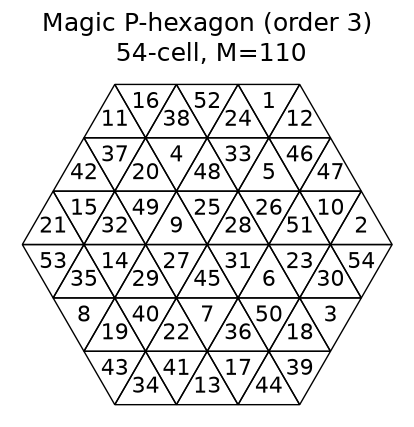

In [10]:
text = '''
Tried 134217728 branches, 418 bases, 1.2 s
Tried 268435456 branches, 804 bases, 2.4 s
Tried 402653184 branches, 1209 bases, 3.7 s
Tried 536870912 branches, 1569 bases, 4.9 s
Solution 1:
ROWS = [
    ["HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1"],
    ["HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1"],
    ["HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1"],
    ["HCA1", "YCA1", "CA1", "C1", "A1", "B0", "A2", "C2", "AC2", "ZAC2", "HAC2"],
    ["HC1", "YAC1", "AC1", "DB0", "D0", "BD0", "CA2", "ZCA2", "HC2"],
    ["HAC1", "HDB0", "XDB0", "HD0", "XBD0", "HBD0", "HCA2"]
]
NUMBERS = [
    [11, 16, 38, 52, 24, 1, 12],
    [42, 37, 20, 4, 48, 33, 5, 46, 47],
    [21, 15, 32, 49, 9, 25, 28, 26, 51, 10, 2],
    [53, 35, 14, 29, 27, 45, 31, 6, 23, 30, 54],
    [8, 19, 40, 22, 7, 36, 50, 18, 3],
    [43, 34, 41, 13, 17, 44, 39]
]
Found 1 solution(s); 1626 bases, 556600826 branches, 5.09 CPU s
'''

print(text)
plot_jigusugwimundo(
    magicPorder3,
    sides=(3, 3, 3, 3, 3, 3),
    title="Magic P-hexagon (order 3)\n 54-cell, M=110",
    fontsize=16,
    figsize=(4, 4),
)

Tried 134217728 branches, 443 bases, 1.3 s
Tried 268435456 branches, 887 bases, 2.6 s
Tried 402653184 branches, 1232 bases, 3.8 s
Tried 536870912 branches, 1511 bases, 5.1 s
Tried 671088640 branches, 1867 bases, 6.4 s
Tried 805306368 branches, 2203 bases, 7.6 s
Tried 939524096 branches, 2581 bases, 8.8 s
Tried 1073741824 branches, 2906 bases, 10.0 s
Tried 1207959552 branches, 3257 bases, 11.3 s
Tried 1342177280 branches, 3618 bases, 12.5 s
Tried 1476395008 branches, 3922 bases, 13.7 s
Tried 1610612736 branches, 4288 bases, 14.9 s
Tried 1744830464 branches, 4622 bases, 16.1 s
Tried 1879048192 branches, 4975 bases, 17.3 s
Tried 2013265920 branches, 5288 bases, 18.5 s
Tried 2147483648 branches, 5626 bases, 19.7 s
Tried 2281701376 branches, 5993 bases, 20.9 s
Tried 2415919104 branches, 6363 bases, 22.1 s
Tried 2550136832 branches, 6664 bases, 23.3 s
Tried 2684354560 branches, 6971 bases, 24.5 s
Tried 2818572288 branches, 7335 bases, 25.7 s
Tried 2952790016 branches, 7687 bases, 26.9 s
Trie

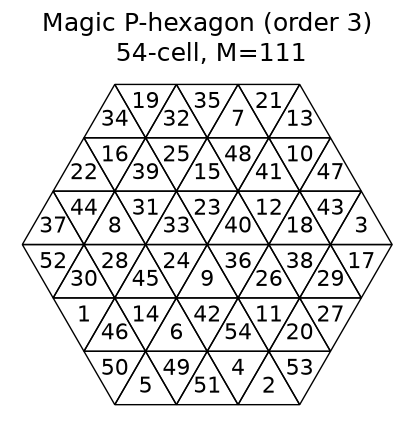

In [11]:
text111 = '''Tried 134217728 branches, 443 bases, 1.3 s
Tried 268435456 branches, 887 bases, 2.6 s
Tried 402653184 branches, 1232 bases, 3.8 s
Tried 536870912 branches, 1511 bases, 5.1 s
Tried 671088640 branches, 1867 bases, 6.4 s
Tried 805306368 branches, 2203 bases, 7.6 s
Tried 939524096 branches, 2581 bases, 8.8 s
Tried 1073741824 branches, 2906 bases, 10.0 s
Tried 1207959552 branches, 3257 bases, 11.3 s
Tried 1342177280 branches, 3618 bases, 12.5 s
Tried 1476395008 branches, 3922 bases, 13.7 s
Tried 1610612736 branches, 4288 bases, 14.9 s
Tried 1744830464 branches, 4622 bases, 16.1 s
Tried 1879048192 branches, 4975 bases, 17.3 s
Tried 2013265920 branches, 5288 bases, 18.5 s
Tried 2147483648 branches, 5626 bases, 19.7 s
Tried 2281701376 branches, 5993 bases, 20.9 s
Tried 2415919104 branches, 6363 bases, 22.1 s
Tried 2550136832 branches, 6664 bases, 23.3 s
Tried 2684354560 branches, 6971 bases, 24.5 s
Tried 2818572288 branches, 7335 bases, 25.7 s
Tried 2952790016 branches, 7687 bases, 26.9 s
Tried 3087007744 branches, 8038 bases, 28.1 s
Tried 3221225472 branches, 8343 bases, 29.3 s
Tried 3355443200 branches, 8683 bases, 30.5 s
Tried 3489660928 branches, 9028 bases, 31.7 s
Solution 1:
ROWS = [
    ["HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1"],
    ["HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1"],
    ["HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1"],
    ["HCA1", "YCA1", "CA1", "C1", "A1", "B0", "A2", "C2", "AC2", "ZAC2", "HAC2"],
    ["HC1", "YAC1", "AC1", "DB0", "D0", "BD0", "CA2", "ZCA2", "HC2"],
    ["HAC1", "HDB0", "XDB0", "HD0", "XBD0", "HBD0", "HCA2"]
]
NUMBERS = [
    [34, 19, 32, 35, 7, 21, 13],
    [22, 16, 39, 25, 15, 48, 41, 10, 47],
    [37, 44, 8, 31, 33, 23, 40, 12, 18, 43, 3],
    [52, 30, 28, 45, 24, 9, 36, 26, 38, 29, 17],
    [1, 46, 14, 6, 42, 54, 11, 20, 27],
    [50, 5, 49, 51, 4, 2, 53]
]
Found 1 solution(s); 9322 bases, 3597495352 branches, 32.71 CPU s'''


magicPorder3_111 = [
    [34, 19, 32, 35, 7, 21, 13],
    [22, 16, 39, 25, 15, 48, 41, 10, 47],
    [37, 44, 8, 31, 33, 23, 40, 12, 18, 43, 3],
    [52, 30, 28, 45, 24, 9, 36, 26, 38, 29, 17],
    [1, 46, 14, 6, 42, 54, 11, 20, 27],
    [50, 5, 49, 51, 4, 2, 53]
]
print(text111)

plot_jigusugwimundo(
    magicPorder3_111,
    sides=(3, 3, 3, 3, 3, 3),
    title="Magic P-hexagon (order 3)\n 54-cell, M=111",
    fontsize=16,
    figsize=(4, 4),
)

Solution 1:
ROWS = [
    ["HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1"],
    ["HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1"],
    ["HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1"],
    ["HCA1", "YCA1", "CA1", "C1", "A1", "B0", "A2", "C2", "AC2", "ZAC2", "HAC2"],
    ["HC1", "YAC1", "AC1", "DB0", "D0", "BD0", "CA2", "ZCA2", "HC2"],
    ["HAC1", "HDB0", "XDB0", "HD0", "XBD0", "HBD0", "HCA2"]
]
NUMBERS = [
    [13, 27, 25, 18, 15, 49, 43],
    [48, 20, 31, 42, 14, 30, 53, 5, 11],
    [3, 38, 23, 19, 39, 26, 33, 24, 2, 52, 47],
    [21, 22, 32, 35, 28, 10, 29, 40, 34, 36, 1],
    [37, 54, 17, 6, 45, 51, 9, 12, 41],
    [4, 16, 44, 46, 7, 8, 50]
]
Found 1 solution(s); 152 bases, 51025200 branches, 0.48 CPU s


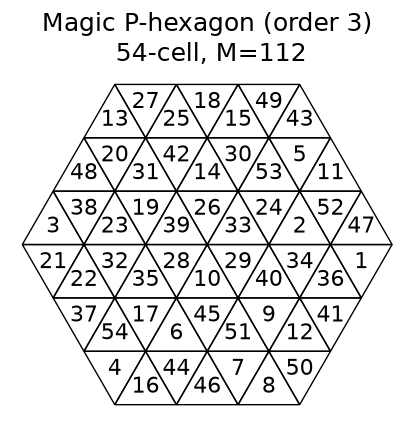

In [12]:
text112 = '''Solution 1:
ROWS = [
    ["HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1"],
    ["HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1"],
    ["HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1"],
    ["HCA1", "YCA1", "CA1", "C1", "A1", "B0", "A2", "C2", "AC2", "ZAC2", "HAC2"],
    ["HC1", "YAC1", "AC1", "DB0", "D0", "BD0", "CA2", "ZCA2", "HC2"],
    ["HAC1", "HDB0", "XDB0", "HD0", "XBD0", "HBD0", "HCA2"]
]
NUMBERS = [
    [13, 27, 25, 18, 15, 49, 43],
    [48, 20, 31, 42, 14, 30, 53, 5, 11],
    [3, 38, 23, 19, 39, 26, 33, 24, 2, 52, 47],
    [21, 22, 32, 35, 28, 10, 29, 40, 34, 36, 1],
    [37, 54, 17, 6, 45, 51, 9, 12, 41],
    [4, 16, 44, 46, 7, 8, 50]
]
Found 1 solution(s); 152 bases, 51025200 branches, 0.48 CPU s'''
magicPorder3_112 = [
    [13, 27, 25, 18, 15, 49, 43],
    [48, 20, 31, 42, 14, 30, 53, 5, 11],
    [3, 38, 23, 19, 39, 26, 33, 24, 2, 52, 47],
    [21, 22, 32, 35, 28, 10, 29, 40, 34, 36, 1],
    [37, 54, 17, 6, 45, 51, 9, 12, 41],
    [4, 16, 44, 46, 7, 8, 50]
]
print(text112)

plot_jigusugwimundo(
    magicPorder3_112,
    sides=(3, 3, 3, 3, 3, 3),
    title="Magic P-hexagon (order 3)\n 54-cell, M=112",
    fontsize=16,
    figsize=(4, 4),
)

Tried 134217728 branches, 386 bases, 1.2 s
Tried 268435456 branches, 770 bases, 2.4 s
Tried 402653184 branches, 1117 bases, 3.6 s
Tried 536870912 branches, 1473 bases, 4.8 s
Tried 671088640 branches, 1799 bases, 6.0 s
Tried 805306368 branches, 2111 bases, 7.2 s
Tried 939524096 branches, 2487 bases, 8.4 s
Tried 1073741824 branches, 2893 bases, 9.6 s
Tried 1207959552 branches, 3233 bases, 10.8 s
Tried 1342177280 branches, 3607 bases, 12.1 s
Tried 1476395008 branches, 3924 bases, 13.3 s
Tried 1610612736 branches, 4294 bases, 14.5 s
Tried 1744830464 branches, 4644 bases, 15.7 s
Tried 1879048192 branches, 5010 bases, 16.9 s
Tried 2013265920 branches, 5388 bases, 18.1 s
Tried 2147483648 branches, 5684 bases, 19.3 s
Tried 2281701376 branches, 6046 bases, 20.4 s
Solution 1:
ROWS = [
    ["HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1"],
    ["HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1"],
    ["HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1"],
 

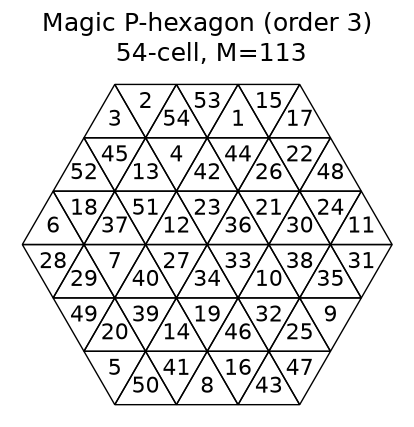

In [13]:
text113 = '''Tried 134217728 branches, 386 bases, 1.2 s
Tried 268435456 branches, 770 bases, 2.4 s
Tried 402653184 branches, 1117 bases, 3.6 s
Tried 536870912 branches, 1473 bases, 4.8 s
Tried 671088640 branches, 1799 bases, 6.0 s
Tried 805306368 branches, 2111 bases, 7.2 s
Tried 939524096 branches, 2487 bases, 8.4 s
Tried 1073741824 branches, 2893 bases, 9.6 s
Tried 1207959552 branches, 3233 bases, 10.8 s
Tried 1342177280 branches, 3607 bases, 12.1 s
Tried 1476395008 branches, 3924 bases, 13.3 s
Tried 1610612736 branches, 4294 bases, 14.5 s
Tried 1744830464 branches, 4644 bases, 15.7 s
Tried 1879048192 branches, 5010 bases, 16.9 s
Tried 2013265920 branches, 5388 bases, 18.1 s
Tried 2147483648 branches, 5684 bases, 19.3 s
Tried 2281701376 branches, 6046 bases, 20.4 s
Solution 1:
ROWS = [
    ["HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1"],
    ["HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1"],
    ["HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1"],
    ["HCA1", "YCA1", "CA1", "C1", "A1", "B0", "A2", "C2", "AC2", "ZAC2", "HAC2"],
    ["HC1", "YAC1", "AC1", "DB0", "D0", "BD0", "CA2", "ZCA2", "HC2"],
    ["HAC1", "HDB0", "XDB0", "HD0", "XBD0", "HBD0", "HCA2"]
]
NUMBERS = [
    [3, 2, 54, 53, 1, 15, 17],
    [52, 45, 13, 4, 42, 44, 26, 22, 48],
    [6, 18, 37, 51, 12, 23, 36, 21, 30, 24, 11],
    [28, 29, 7, 40, 27, 34, 33, 10, 38, 35, 31],
    [49, 20, 39, 14, 19, 46, 32, 25, 9],
    [5, 50, 41, 8, 16, 43, 47]
]
Found 1 solution(s); 6137 bases, 2317396936 branches, 20.75 CPU s'''
magicPorder3_113 = [
    [3, 2, 54, 53, 1, 15, 17],
    [52, 45, 13, 4, 42, 44, 26, 22, 48],
    [6, 18, 37, 51, 12, 23, 36, 21, 30, 24, 11],
    [28, 29, 7, 40, 27, 34, 33, 10, 38, 35, 31],
    [49, 20, 39, 14, 19, 46, 32, 25, 9],
    [5, 50, 41, 8, 16, 43, 47]
]
print(text113)

plot_jigusugwimundo(
    magicPorder3_113,
    sides=(3, 3, 3, 3, 3, 3),
    title="Magic P-hexagon (order 3)\n 54-cell, M=113",
    fontsize=16,
    figsize=(4, 4),
)

Tried 134217728 branches, 338 bases, 1.2 s
Tried 268435456 branches, 723 bases, 2.4 s
Tried 402653184 branches, 1042 bases, 3.6 s
Tried 536870912 branches, 1399 bases, 4.8 s
Tried 671088640 branches, 1720 bases, 6.0 s
Tried 805306368 branches, 2053 bases, 7.2 s
Tried 939524096 branches, 2441 bases, 8.5 s
Tried 1073741824 branches, 2804 bases, 9.7 s
Tried 1207959552 branches, 3146 bases, 10.9 s
Tried 1342177280 branches, 3434 bases, 12.1 s
Tried 1476395008 branches, 3787 bases, 13.3 s
Tried 1610612736 branches, 4105 bases, 14.5 s
Tried 1744830464 branches, 4470 bases, 15.7 s
Solution 1:
ROWS = [
    ["HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1"],
    ["HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1"],
    ["HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1"],
    ["HCA1", "YCA1", "CA1", "C1", "A1", "B0", "A2", "C2", "AC2", "ZAC2", "HAC2"],
    ["HC1", "YAC1", "AC1", "DB0", "D0", "BD0", "CA2", "ZCA2", "HC2"],
    ["HAC1", "HDB0", "XDB0", "HD0

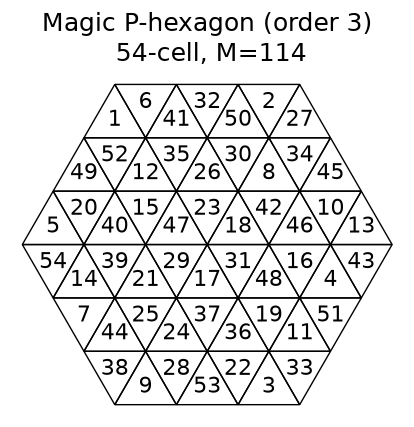

In [14]:
text114 = '''Tried 134217728 branches, 338 bases, 1.2 s
Tried 268435456 branches, 723 bases, 2.4 s
Tried 402653184 branches, 1042 bases, 3.6 s
Tried 536870912 branches, 1399 bases, 4.8 s
Tried 671088640 branches, 1720 bases, 6.0 s
Tried 805306368 branches, 2053 bases, 7.2 s
Tried 939524096 branches, 2441 bases, 8.5 s
Tried 1073741824 branches, 2804 bases, 9.7 s
Tried 1207959552 branches, 3146 bases, 10.9 s
Tried 1342177280 branches, 3434 bases, 12.1 s
Tried 1476395008 branches, 3787 bases, 13.3 s
Tried 1610612736 branches, 4105 bases, 14.5 s
Tried 1744830464 branches, 4470 bases, 15.7 s
Solution 1:
ROWS = [
    ["HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1"],
    ["HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1"],
    ["HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1"],
    ["HCA1", "YCA1", "CA1", "C1", "A1", "B0", "A2", "C2", "AC2", "ZAC2", "HAC2"],
    ["HC1", "YAC1", "AC1", "DB0", "D0", "BD0", "CA2", "ZCA2", "HC2"],
    ["HAC1", "HDB0", "XDB0", "HD0", "XBD0", "HBD0", "HCA2"]
]
NUMBERS = [
    [1, 6, 41, 32, 50, 2, 27],
    [49, 52, 12, 35, 26, 30, 8, 34, 45],
    [5, 20, 40, 15, 47, 23, 18, 42, 46, 10, 13],
    [54, 14, 39, 21, 29, 17, 31, 48, 16, 4, 43],
    [7, 44, 25, 24, 37, 36, 19, 11, 51],
    [38, 9, 28, 53, 22, 3, 33]
]
Found 1 solution(s); 4837 bases, 1875909690 branches, 16.87 CPU s'''
magicPorder3_114 = [
    [1, 6, 41, 32, 50, 2, 27],
    [49, 52, 12, 35, 26, 30, 8, 34, 45],
    [5, 20, 40, 15, 47, 23, 18, 42, 46, 10, 13],
    [54, 14, 39, 21, 29, 17, 31, 48, 16, 4, 43],
    [7, 44, 25, 24, 37, 36, 19, 11, 51],
    [38, 9, 28, 53, 22, 3, 33]
]
print(text114)

plot_jigusugwimundo(
    magicPorder3_114,
    sides=(3, 3, 3, 3, 3, 3),
    title="Magic P-hexagon (order 3)\n 54-cell, M=114",
    fontsize=16,
    figsize=(4, 4),
)

Solution 1:
ROWS = [
    ["HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1"],
    ["HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1"],
    ["HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1"],
    ["HCA1", "YCA1", "CA1", "C1", "A1", "B0", "A2", "C2", "AC2", "ZAC2", "HAC2"],
    ["HC1", "YAC1", "AC1", "DB0", "D0", "BD0", "CA2", "ZCA2", "HC2"],
    ["HAC1", "HDB0", "XDB0", "HD0", "XBD0", "HBD0", "HCA2"]
]
NUMBERS = [
    [20, 3, 31, 41, 19, 38, 21],
    [35, 48, 12, 40, 32, 17, 47, 2, 45],
    [14, 24, 42, 15, 46, 26, 11, 49, 8, 52, 10],
    [5, 23, 34, 16, 28, 25, 29, 50, 6, 51, 4],
    [53, 18, 37, 44, 33, 13, 30, 22, 54],
    [7, 43, 1, 27, 39, 36, 9]
]
Found 1 solution(s); 232 bases, 80970709 branches, 0.73 CPU s


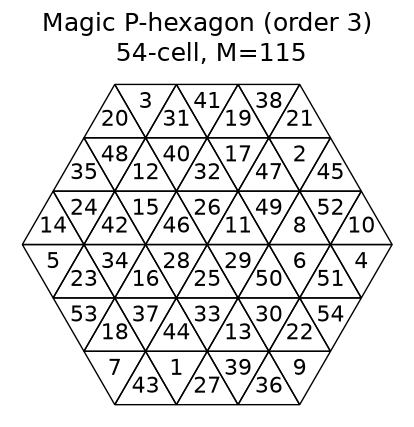

In [15]:
text115 = '''Solution 1:
ROWS = [
    ["HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1"],
    ["HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1"],
    ["HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1"],
    ["HCA1", "YCA1", "CA1", "C1", "A1", "B0", "A2", "C2", "AC2", "ZAC2", "HAC2"],
    ["HC1", "YAC1", "AC1", "DB0", "D0", "BD0", "CA2", "ZCA2", "HC2"],
    ["HAC1", "HDB0", "XDB0", "HD0", "XBD0", "HBD0", "HCA2"]
]
NUMBERS = [
    [20, 3, 31, 41, 19, 38, 21],
    [35, 48, 12, 40, 32, 17, 47, 2, 45],
    [14, 24, 42, 15, 46, 26, 11, 49, 8, 52, 10],
    [5, 23, 34, 16, 28, 25, 29, 50, 6, 51, 4],
    [53, 18, 37, 44, 33, 13, 30, 22, 54],
    [7, 43, 1, 27, 39, 36, 9]
]
Found 1 solution(s); 232 bases, 80970709 branches, 0.73 CPU s'''
magicPorder3_115 = [
    [20, 3, 31, 41, 19, 38, 21],
    [35, 48, 12, 40, 32, 17, 47, 2, 45],
    [14, 24, 42, 15, 46, 26, 11, 49, 8, 52, 10],
    [5, 23, 34, 16, 28, 25, 29, 50, 6, 51, 4],
    [53, 18, 37, 44, 33, 13, 30, 22, 54],
    [7, 43, 1, 27, 39, 36, 9]
]
print(text115)

plot_jigusugwimundo(
    magicPorder3_115,
    sides=(3, 3, 3, 3, 3, 3),
    title="Magic P-hexagon (order 3)\n 54-cell, M=115",
    fontsize=16,
    figsize=(4, 4),
)

Tried 134217728 branches, 320 bases, 1.2 s
Tried 268435456 branches, 674 bases, 2.4 s
Tried 402653184 branches, 1006 bases, 3.6 s
Tried 536870912 branches, 1283 bases, 4.8 s
Tried 671088640 branches, 1598 bases, 6.0 s
Tried 805306368 branches, 1954 bases, 7.3 s
Tried 939524096 branches, 2291 bases, 8.5 s
Tried 1073741824 branches, 2619 bases, 9.7 s
Tried 1207959552 branches, 2925 bases, 10.9 s
Tried 1342177280 branches, 3253 bases, 12.1 s
Tried 1476395008 branches, 3548 bases, 13.3 s
Tried 1610612736 branches, 3848 bases, 14.5 s
Tried 1744830464 branches, 4186 bases, 15.7 s
Tried 1879048192 branches, 4503 bases, 16.9 s
Tried 2013265920 branches, 4800 bases, 18.1 s
Tried 2147483648 branches, 5126 bases, 19.3 s
Tried 2281701376 branches, 5431 bases, 20.4 s
Tried 2415919104 branches, 5768 bases, 21.6 s
Tried 2550136832 branches, 6114 bases, 22.8 s
Tried 2684354560 branches, 6471 bases, 24.0 s
Tried 2818572288 branches, 6804 bases, 25.2 s
Tried 2952790016 branches, 7099 bases, 26.4 s
Tried

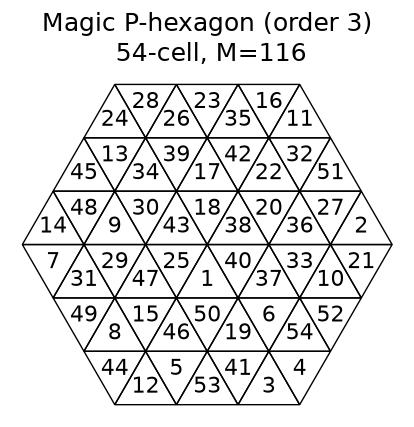

In [16]:
text116 = '''Tried 134217728 branches, 320 bases, 1.2 s
Tried 268435456 branches, 674 bases, 2.4 s
Tried 402653184 branches, 1006 bases, 3.6 s
Tried 536870912 branches, 1283 bases, 4.8 s
Tried 671088640 branches, 1598 bases, 6.0 s
Tried 805306368 branches, 1954 bases, 7.3 s
Tried 939524096 branches, 2291 bases, 8.5 s
Tried 1073741824 branches, 2619 bases, 9.7 s
Tried 1207959552 branches, 2925 bases, 10.9 s
Tried 1342177280 branches, 3253 bases, 12.1 s
Tried 1476395008 branches, 3548 bases, 13.3 s
Tried 1610612736 branches, 3848 bases, 14.5 s
Tried 1744830464 branches, 4186 bases, 15.7 s
Tried 1879048192 branches, 4503 bases, 16.9 s
Tried 2013265920 branches, 4800 bases, 18.1 s
Tried 2147483648 branches, 5126 bases, 19.3 s
Tried 2281701376 branches, 5431 bases, 20.4 s
Tried 2415919104 branches, 5768 bases, 21.6 s
Tried 2550136832 branches, 6114 bases, 22.8 s
Tried 2684354560 branches, 6471 bases, 24.0 s
Tried 2818572288 branches, 6804 bases, 25.2 s
Tried 2952790016 branches, 7099 bases, 26.4 s
Tried 3087007744 branches, 7403 bases, 27.5 s
Tried 3221225472 branches, 7707 bases, 28.8 s
Tried 3355443200 branches, 8018 bases, 29.9 s
Tried 3489660928 branches, 8326 bases, 31.1 s
Tried 3623878656 branches, 8657 bases, 32.3 s
Tried 3758096384 branches, 8980 bases, 33.5 s
Tried 3892314112 branches, 9321 bases, 34.7 s
Tried 4026531840 branches, 9641 bases, 35.8 s
Tried 4160749568 branches, 9964 bases, 37.0 s
Tried 4294967296 branches, 10263 bases, 38.2 s
Tried 4429185024 branches, 10581 bases, 39.4 s
Tried 4563402752 branches, 10899 bases, 40.6 s
Tried 4697620480 branches, 11226 bases, 41.8 s
Tried 4831838208 branches, 11550 bases, 43.0 s
Tried 4966055936 branches, 11847 bases, 44.2 s
Tried 5100273664 branches, 12179 bases, 45.3 s
Tried 5234491392 branches, 12506 bases, 46.5 s
Tried 5368709120 branches, 12860 bases, 47.7 s
Tried 5502926848 branches, 13192 bases, 48.9 s
Tried 5637144576 branches, 13469 bases, 50.0 s
Tried 5771362304 branches, 13767 bases, 51.2 s
Tried 5905580032 branches, 14083 bases, 52.4 s
Tried 6039797760 branches, 14377 bases, 53.5 s
Tried 6174015488 branches, 14688 bases, 54.7 s
Tried 6308233216 branches, 14984 bases, 55.9 s
Tried 6442450944 branches, 15295 bases, 57.0 s
Tried 6576668672 branches, 15602 bases, 58.2 s
Tried 6710886400 branches, 15901 bases, 59.4 s
Tried 6845104128 branches, 16210 bases, 60.6 s
Tried 6979321856 branches, 16520 bases, 61.7 s
Tried 7113539584 branches, 16862 bases, 62.9 s
Tried 7247757312 branches, 17158 bases, 64.1 s
Tried 7381975040 branches, 17462 bases, 65.2 s
Tried 7516192768 branches, 17761 bases, 66.4 s
Tried 7650410496 branches, 18073 bases, 67.6 s
Tried 7784628224 branches, 18378 bases, 68.7 s
Tried 7918845952 branches, 18657 bases, 69.9 s
Tried 8053063680 branches, 18947 bases, 71.1 s
Tried 8187281408 branches, 19229 bases, 72.2 s
Tried 8321499136 branches, 19542 bases, 73.4 s
Tried 8455716864 branches, 19860 bases, 74.6 s
Tried 8589934592 branches, 20148 bases, 75.8 s
Tried 8724152320 branches, 20459 bases, 77.0 s
Tried 8858370048 branches, 20770 bases, 78.1 s
Tried 8992587776 branches, 21111 bases, 79.3 s
Tried 9126805504 branches, 21416 bases, 80.5 s
Tried 9261023232 branches, 21713 bases, 81.6 s
Tried 9395240960 branches, 22017 bases, 82.8 s
Tried 9529458688 branches, 22304 bases, 84.0 s
Tried 9663676416 branches, 22575 bases, 85.1 s
Tried 9797894144 branches, 22858 bases, 86.3 s
Tried 9932111872 branches, 23134 bases, 87.4 s
Solution 1:
ROWS = [
    ["HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1"],
    ["HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1"],
    ["HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1"],
    ["HCA1", "YCA1", "CA1", "C1", "A1", "B0", "A2", "C2", "AC2", "ZAC2", "HAC2"],
    ["HC1", "YAC1", "AC1", "DB0", "D0", "BD0", "CA2", "ZCA2", "HC2"],
    ["HAC1", "HDB0", "XDB0", "HD0", "XBD0", "HBD0", "HCA2"]
]
NUMBERS = [
    [24, 28, 26, 23, 35, 16, 11],
    [45, 13, 34, 39, 17, 42, 22, 32, 51],
    [14, 48, 9, 30, 43, 18, 38, 20, 36, 27, 2],
    [7, 31, 29, 47, 25, 1, 40, 37, 33, 10, 21],
    [49, 8, 15, 46, 50, 19, 6, 54, 52],
    [44, 12, 5, 53, 41, 3, 4]
]
Found 1 solution(s); 23297 bases, 10004914765 branches, 88.08 CPU s'''
magicPorder3_116 = [
    [24, 28, 26, 23, 35, 16, 11],
    [45, 13, 34, 39, 17, 42, 22, 32, 51],
    [14, 48, 9, 30, 43, 18, 38, 20, 36, 27, 2],
    [7, 31, 29, 47, 25, 1, 40, 37, 33, 10, 21],
    [49, 8, 15, 46, 50, 19, 6, 54, 52],
    [44, 12, 5, 53, 41, 3, 4]
]
print(text116)

plot_jigusugwimundo(
    magicPorder3_116,
    sides=(3, 3, 3, 3, 3, 3),
    title="Magic P-hexagon (order 3)\n 54-cell, M=116",
    fontsize=16,
    figsize=(4, 4),
)

Tried 134217728 branches, 316 bases, 1.2 s
Tried 268435456 branches, 640 bases, 2.4 s
Tried 402653184 branches, 948 bases, 3.6 s
Tried 536870912 branches, 1258 bases, 4.9 s
Tried 671088640 branches, 1575 bases, 6.1 s
Tried 805306368 branches, 1906 bases, 7.3 s
Tried 939524096 branches, 2226 bases, 8.5 s
Tried 1073741824 branches, 2539 bases, 9.7 s
Tried 1207959552 branches, 2854 bases, 10.9 s
Tried 1342177280 branches, 3164 bases, 12.1 s
Tried 1476395008 branches, 3475 bases, 13.3 s
Tried 1610612736 branches, 3793 bases, 14.5 s
Tried 1744830464 branches, 4123 bases, 15.7 s
Tried 1879048192 branches, 4435 bases, 16.9 s
Tried 2013265920 branches, 4723 bases, 18.0 s
Tried 2147483648 branches, 5039 bases, 19.2 s
Tried 2281701376 branches, 5332 bases, 20.4 s
Tried 2415919104 branches, 5658 bases, 21.6 s
Tried 2550136832 branches, 6011 bases, 22.8 s
Tried 2684354560 branches, 6335 bases, 24.0 s
Tried 2818572288 branches, 6629 bases, 25.2 s
Tried 2952790016 branches, 6913 bases, 26.4 s
Tried 

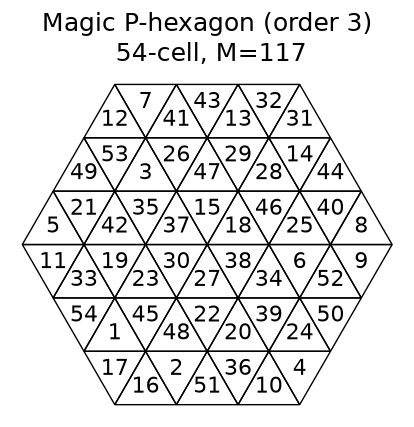

In [17]:
text117 = '''Tried 134217728 branches, 316 bases, 1.2 s
Tried 268435456 branches, 640 bases, 2.4 s
Tried 402653184 branches, 948 bases, 3.6 s
Tried 536870912 branches, 1258 bases, 4.9 s
Tried 671088640 branches, 1575 bases, 6.1 s
Tried 805306368 branches, 1906 bases, 7.3 s
Tried 939524096 branches, 2226 bases, 8.5 s
Tried 1073741824 branches, 2539 bases, 9.7 s
Tried 1207959552 branches, 2854 bases, 10.9 s
Tried 1342177280 branches, 3164 bases, 12.1 s
Tried 1476395008 branches, 3475 bases, 13.3 s
Tried 1610612736 branches, 3793 bases, 14.5 s
Tried 1744830464 branches, 4123 bases, 15.7 s
Tried 1879048192 branches, 4435 bases, 16.9 s
Tried 2013265920 branches, 4723 bases, 18.0 s
Tried 2147483648 branches, 5039 bases, 19.2 s
Tried 2281701376 branches, 5332 bases, 20.4 s
Tried 2415919104 branches, 5658 bases, 21.6 s
Tried 2550136832 branches, 6011 bases, 22.8 s
Tried 2684354560 branches, 6335 bases, 24.0 s
Tried 2818572288 branches, 6629 bases, 25.2 s
Tried 2952790016 branches, 6913 bases, 26.4 s
Tried 3087007744 branches, 7211 bases, 27.5 s
Tried 3221225472 branches, 7515 bases, 28.8 s
Tried 3355443200 branches, 7835 bases, 29.9 s
Tried 3489660928 branches, 8141 bases, 31.1 s
Tried 3623878656 branches, 8483 bases, 32.3 s
Tried 3758096384 branches, 8784 bases, 33.5 s
Tried 3892314112 branches, 9098 bases, 34.7 s
Tried 4026531840 branches, 9405 bases, 35.9 s
Tried 4160749568 branches, 9667 bases, 37.1 s
Tried 4294967296 branches, 9967 bases, 38.3 s
Tried 4429185024 branches, 10288 bases, 39.4 s
Tried 4563402752 branches, 10608 bases, 40.6 s
Tried 4697620480 branches, 10934 bases, 41.8 s
Tried 4831838208 branches, 11255 bases, 42.9 s
Tried 4966055936 branches, 11584 bases, 44.1 s
Tried 5100273664 branches, 11896 bases, 45.3 s
Tried 5234491392 branches, 12184 bases, 46.4 s
Tried 5368709120 branches, 12471 bases, 47.6 s
Tried 5502926848 branches, 12768 bases, 48.8 s
Tried 5637144576 branches, 13050 bases, 50.0 s
Tried 5771362304 branches, 13338 bases, 51.1 s
Tried 5905580032 branches, 13637 bases, 52.3 s
Tried 6039797760 branches, 13937 bases, 53.5 s
Tried 6174015488 branches, 14229 bases, 54.6 s
Tried 6308233216 branches, 14538 bases, 55.8 s
Tried 6442450944 branches, 14854 bases, 57.0 s
Tried 6576668672 branches, 15178 bases, 58.1 s
Tried 6710886400 branches, 15484 bases, 59.3 s
Tried 6845104128 branches, 15760 bases, 60.5 s
Tried 6979321856 branches, 16045 bases, 61.7 s
Tried 7113539584 branches, 16317 bases, 62.9 s
Tried 7247757312 branches, 16603 bases, 64.0 s
Tried 7381975040 branches, 16884 bases, 65.2 s
Tried 7516192768 branches, 17171 bases, 66.3 s
Tried 7650410496 branches, 17466 bases, 67.5 s
Tried 7784628224 branches, 17768 bases, 68.7 s
Tried 7918845952 branches, 18061 bases, 69.8 s
Tried 8053063680 branches, 18332 bases, 71.0 s
Tried 8187281408 branches, 18621 bases, 72.1 s
Tried 8321499136 branches, 18931 bases, 73.3 s
Tried 8455716864 branches, 19270 bases, 74.4 s
Tried 8589934592 branches, 19579 bases, 75.6 s
Tried 8724152320 branches, 19846 bases, 76.8 s
Tried 8858370048 branches, 20132 bases, 77.9 s
Tried 8992587776 branches, 20413 bases, 79.1 s
Tried 9126805504 branches, 20694 bases, 80.2 s
Tried 9261023232 branches, 20980 bases, 81.4 s
Tried 9395240960 branches, 21250 bases, 82.5 s
Tried 9529458688 branches, 21520 bases, 83.7 s
Tried 9663676416 branches, 21805 bases, 84.8 s
Tried 9797894144 branches, 22093 bases, 86.0 s
Tried 9932111872 branches, 22366 bases, 87.1 s
Tried 10066329600 branches, 22640 bases, 88.3 s
Tried 10200547328 branches, 22909 bases, 89.4 s
Tried 10334765056 branches, 23194 bases, 90.6 s
Tried 10468982784 branches, 23493 bases, 91.7 s
Tried 10603200512 branches, 23795 bases, 92.9 s
Tried 10737418240 branches, 24059 bases, 94.0 s
Tried 10871635968 branches, 24342 bases, 95.1 s
Tried 11005853696 branches, 24635 bases, 96.3 s
Tried 11140071424 branches, 24925 bases, 97.4 s
Tried 11274289152 branches, 25194 bases, 98.6 s
Tried 11408506880 branches, 25466 bases, 99.7 s
Tried 11542724608 branches, 25732 bases, 100.9 s
Tried 11676942336 branches, 26016 bases, 102.0 s
Tried 11811160064 branches, 26288 bases, 103.1 s
Tried 11945377792 branches, 26542 bases, 104.3 s
Tried 12079595520 branches, 26797 bases, 105.4 s
Tried 12213813248 branches, 27073 bases, 106.6 s
Tried 12348030976 branches, 27357 bases, 107.7 s
Tried 12482248704 branches, 27641 bases, 108.8 s
Tried 12616466432 branches, 27902 bases, 110.0 s
Tried 12750684160 branches, 28175 bases, 111.1 s
Tried 12884901888 branches, 28473 bases, 112.3 s
Tried 13019119616 branches, 28784 bases, 113.4 s
Tried 13153337344 branches, 29073 bases, 114.6 s
Tried 13287555072 branches, 29359 bases, 115.7 s
Tried 13421772800 branches, 29654 bases, 116.9 s
Tried 13555990528 branches, 29933 bases, 118.0 s
Tried 13690208256 branches, 30207 bases, 119.2 s
Tried 13824425984 branches, 30458 bases, 120.3 s
Tried 13958643712 branches, 30715 bases, 121.4 s
Tried 14092861440 branches, 30978 bases, 122.6 s
Tried 14227079168 branches, 31239 bases, 123.7 s
Tried 14361296896 branches, 31471 bases, 124.9 s
Tried 14495514624 branches, 31715 bases, 126.0 s
Tried 14629732352 branches, 31975 bases, 127.2 s
Tried 14763950080 branches, 32243 bases, 128.3 s
Tried 14898167808 branches, 32495 bases, 129.5 s
Tried 15032385536 branches, 32745 bases, 130.6 s
Tried 15166603264 branches, 33015 bases, 131.8 s
Tried 15300820992 branches, 33290 bases, 132.9 s
Tried 15435038720 branches, 33551 bases, 134.1 s
Tried 15569256448 branches, 33821 bases, 135.2 s
Tried 15703474176 branches, 34097 bases, 136.3 s
Tried 15837691904 branches, 34390 bases, 137.5 s
Tried 15971909632 branches, 34678 bases, 138.6 s
Tried 16106127360 branches, 34964 bases, 139.7 s
Solution 1:
ROWS = [
    ["HDB2", "HAC0", "XAC0", "HC0", "XCA0", "HCA0", "HBD1"],
    ["HD2", "ZDB2", "DB2", "AC0", "C0", "CA0", "BD1", "YBD1", "HD1"],
    ["HBD2", "ZBD2", "BD2", "D2", "B2", "A0", "B1", "D1", "DB1", "YDB1", "HDB1"],
    ["HCA1", "YCA1", "CA1", "C1", "A1", "B0", "A2", "C2", "AC2", "ZAC2", "HAC2"],
    ["HC1", "YAC1", "AC1", "DB0", "D0", "BD0", "CA2", "ZCA2", "HC2"],
    ["HAC1", "HDB0", "XDB0", "HD0", "XBD0", "HBD0", "HCA2"]
]
NUMBERS = [
    [12, 7, 41, 43, 13, 32, 31],
    [49, 53, 3, 26, 47, 29, 28, 14, 44],
    [5, 21, 42, 35, 37, 15, 18, 46, 25, 40, 8],
    [11, 33, 19, 23, 30, 27, 38, 34, 6, 52, 9],
    [54, 1, 45, 48, 22, 20, 39, 24, 50],
    [17, 16, 2, 51, 36, 10, 4]
]
Found 1 solution(s); 35114 bases, 16186729448 branches, 140.41 CPU s'''
magicPorder3_117 = [
    [12, 7, 41, 43, 13, 32, 31],
    [49, 53, 3, 26, 47, 29, 28, 14, 44],
    [5, 21, 42, 35, 37, 15, 18, 46, 25, 40, 8],
    [11, 33, 19, 23, 30, 27, 38, 34, 6, 52, 9],
    [54, 1, 45, 48, 22, 20, 39, 24, 50],
    [17, 16, 2, 51, 36, 10, 4]
]
print(text117)

plot_jigusugwimundo(
    magicPorder3_117,
    sides=(3, 3, 3, 3, 3, 3),
    title="Magic P-hexagon (order 3)\n 54-cell, M=117",
    fontsize=16,
    figsize=(4, 4),
)

# The existence of solutions for M>=118 (or M<=102) remains an open problem.